In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

df = pd.read_csv("Customer-Churn-Records.csv")

In [128]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [129]:
df.shape

(10000, 18)

In [130]:
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-nu

In [131]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min 

In [132]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [133]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [134]:
print("\nTarget Variable conversion:")
print(df["Exited"].value_counts())


Target Variable conversion:
Exited
0    7962
1    2038
Name: count, dtype: int64


In [135]:
X = df.drop(columns=["Exited", "Surname", "RowNumber", "CustomerId"])
y = df["Exited"]

In [136]:
X_encoded = pd.get_dummies(X,
columns=["Geography", "Gender", "Card Type"], drop_first=True, dtype=int
)

In [137]:
print("\nShape after encoding:")
print(X_encoded.shape)


Shape after encoding:
(10000, 17)


In [138]:
print("\nFirst few encoded columns:")
print(X_encoded.head())


First few encoded columns:
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Complain  Satisfaction Score  \
0               1        101348.88         1                   2   
1               1        112542.58         1                   3   
2               0        113931.57         1                   3   
3               0         93826.63         0                   5   
4               1         79084.10         0                   5   

   Point Earned  Geography_Germany  Geography_Spain  Gender_Male  \
0           464                  0                0            0   
1           456   

In [139]:
# Train-Test-Split

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded,
y,
test_size = 0.20,
random_state = 42,
stratify = y)

In [141]:
print("\nTraining set shape:")
print(X_train.shape)


Training set shape:
(8000, 17)


In [142]:
print("\nTesting set shape:")
print(X_test.shape)


Testing set shape:
(2000, 17)


In [143]:
# Scale the data

In [144]:
scaler = StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [145]:
import sys

print(sys.executable)

/usr/bin/python3


In [146]:
!{sys.executable} -m pip install imbalanced-learn

In [147]:
from imblearn.over_sampling import SMOTE

print("SMOTE installed successfully!")

SMOTE installed successfully!


In [148]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train)

# Feature Engineering

In [149]:
# AgeGroup
def create_age_group(age):
    if age < 30:
        return "Young"
    elif age < 45:
        return "Adult"
    elif age < 60:
        return "Middle-aged"
    else:
        return "Senior"

df["AgeGroup"] = df["Age"].apply(create_age_group)

df[["Age", "AgeGroup"]].head(10)

,Age,AgeGroup
0,42,Adult
1,41,Adult
2,42,Adult
3,39,Adult
4,43,Adult
5,44,Adult
6,50,Middle-aged
7,29,Young
8,44,Adult
9,27,Young


In [150]:
# Engaged
df["EngagementRisk"] = (
    (df["IsActiveMember"] == 0).astype(int)
    + (df["NumOfProducts"] <= 1).astype(int)
    + (df["Complain"] == 1).astype(int)
)

df[["IsActiveMember", "EngagementRisk"]].head(10)

,IsActiveMember,EngagementRisk
0,1,2
1,1,2
2,0,2
3,0,1
4,1,1
5,0,2
6,1,0
7,0,2
8,1,0
9,1,1


In [151]:
# Tenure_Age_Ratio
df["Tenure_Age_Ratio"] = (
    df["Tenure"] / df["Age"].replace(0, np.nan)
)

df[["Tenure", "Tenure_Age_Ratio"]].head(10)

,Tenure,Tenure_Age_Ratio
0,2,0.047619
1,1,0.024390
2,8,0.190476
3,1,0.025641
4,2,0.046512
5,8,0.181818
6,7,0.140000
7,4,0.137931
8,4,0.090909
9,2,0.074074


In [152]:
# Balance_Salary_Ratio
df["Balance_Salary_Ratio"] = (
    df["Balance"] /
    df["EstimatedSalary"].replace(0, np.nan)
)

df[["Balance", "Balance_Salary_Ratio"]].head(10)

,Balance,Balance_Salary_Ratio
0,0.00,0.000000
1,83807.86,0.744677
2,159660.80,1.401375
3,0.00,0.000000
4,125510.82,1.587055
5,113755.78,0.759604
6,0.00,0.000000
7,115046.74,0.963969
8,142051.07,1.895518
9,134603.88,1.876647


In [153]:
# ZeroBalance
df["ZeroBalance"] = (df["Balance"] == 0).astype(int)
df[["Balance", "ZeroBalance"]].head(10)

,Balance,ZeroBalance
0,0.00,1
1,83807.86,0
2,159660.80,0
3,0.00,1
4,125510.82,0
5,113755.78,0
6,0.00,1
7,115046.74,0
8,142051.07,0
9,134603.88,0


# Model 1 - Logistic Regression

In [154]:
# Build and train logistic regression model

In [155]:
model = LogisticRegression(max_iter = 1000,
                           random_state = 42)

In [156]:
model.fit(X_train_scaled, y_train)
print("\nModel training completed.")


Model training completed.


In [157]:
# Genereate predictions

In [158]:
y_pred_logistic = model.predict(X_test_scaled)
y_prob_logistic = model.predict_proba(X_test_scaled)[:,1]

In [159]:
print("\nFirst 10 predicted classes:")
print(y_pred[:10])


First 10 predicted classes:
[0 0 0 1 0 1 1 0 0 0]


In [160]:
print("\nFirst 10 predicted probabilities:")
print(y_prob[:10])


First 10 predicted probabilities:
[1.04164122e-04 1.04258568e-03 3.15380171e-04 9.97784436e-01
 1.05621017e-03 9.93181196e-01 9.93410448e-01 1.02488936e-03
 2.01293283e-04 4.77825712e-04]


In [161]:
# Understand probabilities

In [162]:
probability_examples = pd.DataFrame({
    "Actual Outcomes": y_test.values[:10],
    "Predicted Probability": y_prob[:10],
    "Predicted Class": y_pred[:10]
})

print("\nProbability examples:")
print(probability_examples)


Probability examples:
   Actual Outcomes  Predicted Probability  Predicted Class
0                0               0.000104                0
1                0               0.001043                0
2                0               0.000315                0
3                1               0.997784                1
4                0               0.001056                0
5                1               0.993181                1
6                1               0.993410                1
7                0               0.001025                0
8                0               0.000201                0
9                0               0.000478                0


# Model Evaluation

In [163]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("---------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Logistic Regression Results
---------------------
Accuracy : 0.9985
Precision: 0.9975429975429976
Recall   : 0.9950980392156863
F1 Score : 0.996319018404908


In [164]:
cm_logistic = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)

Confusion Matrix: [[1591    1]
 [   2  406]]


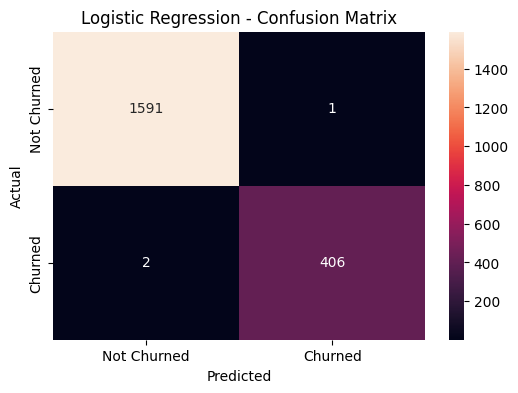

In [165]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=["Not Churned", "Churned"],
    yticklabels=["Not Churned", "Churned"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [166]:
cp_logistic = classification_report(y_test, y_pred)
print("Classification Report:", cp)

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

